# KPCAs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler

## 1. Generación de datos

Utilizamos un dataset compuesto por datos distribuidos en dos círculos concéntricos, cada uno perteneciente a una de las 2 clases

In [10]:
def generate_data():
    X, y = make_circles(n_samples=200, factor=0.3, noise=0.05)
    return X, y

[1 1 0 1 1 1 0 1 1 0 0 0 1 1 1 0 0 1 1 0 0 1 1 1 0 1 0 0 1 0 1 0 0 0 0 0 1
 1 1 1 1 1 1 1 0 1 1 0 1 1 0 0 0 0 1 1 1 1 0 0 0 0 1 0 0 0 1 1 1 1 0 1 0 0
 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0 1 1 0 0 0 0 1 1 0 1 0 1 1 0 1 1 0 0 1
 1 1 1 0 1 1 1 0 1 1 0 0 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 1 0 1 0 0 0 0 1 1 0
 1 1 0 1 1 0 0 1 1 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 1 1 1 1 0 0 1 1 1 0 1 0 0
 1 0 0 0 1 1 0 0 1 1 0 0 0 0 1]


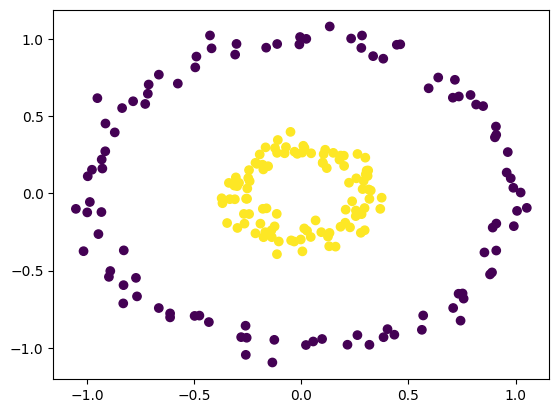

In [12]:
X, y = generate_data()
print(y)

# visualize data
plt.scatter(X[:, 0], X[:, 1], c=y)

## 2. PCA

Transformamos los datos utilizando PCA.

[[ 0.24730362 -0.45667147]
 [-0.47435817  0.34771643]
 [ 0.12344689  1.88002921]
 [ 0.70442931  0.01299747]
 [ 0.03533254  0.72453906]
 [ 0.42957172  0.35296026]
 [ 0.49270702  1.91078629]
 [-0.24635976  0.68478398]
 [-0.35021555 -0.08995399]
 [ 1.67701676  0.9523173 ]
 [ 1.85271551  0.15413499]
 [ 0.5230503   1.90566362]
 [-0.21045251  0.46750158]
 [ 0.00666765 -0.49751251]
 [ 0.02452742  0.53742695]
 [-0.20769874 -1.77520439]
 [-1.20636294 -1.50764856]
 [-0.5471605  -0.46332194]
 [ 0.17777761 -0.62961049]
 [ 1.70291301 -0.65738341]
 [-0.09937259  2.12816554]
 [-0.33346999  0.02386792]
 [ 0.01443802  0.60789907]
 [-0.70688314 -0.10294536]
 [-0.29173163  1.84496345]
 [-0.50341036 -0.40337446]
 [ 1.8877107  -0.14321936]
 [-1.78944827 -0.31118294]
 [ 0.57645214  0.26990629]
 [-1.74954444  0.39510364]
 [-0.16476377  0.52634844]
 [-1.88914132 -0.87824074]
 [-0.89045772  1.75975031]
 [ 1.36338491 -1.37664478]
 [-0.87608371 -1.61505116]
 [-0.65041201 -1.71991243]
 [ 0.36532096 -0.35087499]
 

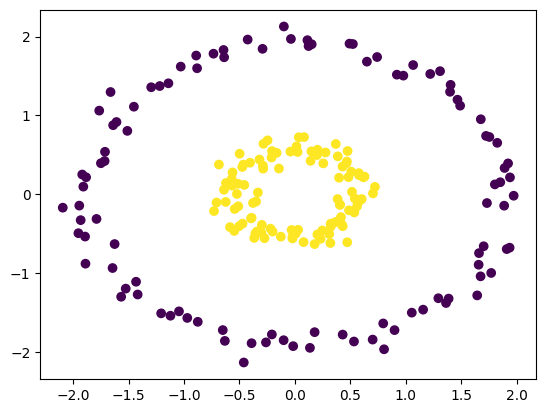

In [17]:
X_std = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_std)
print(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)

¿Qué ocurre con la transformación?

...

## 3. KPCA con Kernel Lineal 

Compara el resultado de PCA con el de KPCA utilizando un kernel **lineal**

[[-0.24730362  0.45667147 -0.        ]
 [ 0.47435817 -0.34771643  0.        ]
 [-0.12344689 -1.88002921  0.        ]
 [-0.70442931 -0.01299747  0.        ]
 [-0.03533254 -0.72453906 -0.        ]
 [-0.42957172 -0.35296026  0.        ]
 [-0.49270702 -1.91078629  0.        ]
 [ 0.24635976 -0.68478398  0.        ]
 [ 0.35021555  0.08995399 -0.        ]
 [-1.67701676 -0.9523173   0.        ]
 [-1.85271551 -0.15413499 -0.        ]
 [-0.5230503  -1.90566362 -0.        ]
 [ 0.21045251 -0.46750158 -0.        ]
 [-0.00666765  0.49751251 -0.        ]
 [-0.02452742 -0.53742695  0.        ]
 [ 0.20769874  1.77520439  0.        ]
 [ 1.20636294  1.50764856 -0.        ]
 [ 0.5471605   0.46332194  0.        ]
 [-0.17777761  0.62961049  0.        ]
 [-1.70291301  0.65738341 -0.        ]
 [ 0.09937259 -2.12816554 -0.        ]
 [ 0.33346999 -0.02386792 -0.        ]
 [-0.01443802 -0.60789907 -0.        ]
 [ 0.70688314  0.10294536 -0.        ]
 [ 0.29173163 -1.84496345  0.        ]
 [ 0.50341036  0.40337446

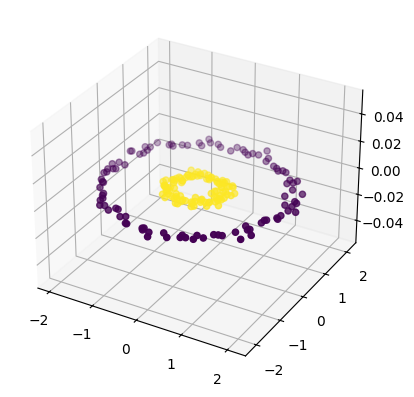

In [18]:
kpca_l = KernelPCA(n_components=3, kernel="linear", gamma=10, fit_inverse_transform=True, alpha=0.1)

X_kpca_l = kpca_l.fit_transform(X_std)
print(X_kpca_l)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X_kpca_l[:, 0], X_kpca_l[:, 1], X_kpca_l[:, 2], c=y, cmap='viridis')

## 4. KPCA con Kernel Polinomial

Observa cómo se transforman los datos utilizando un kernel polinómico. Utiliza 3 valores distintos de **p**

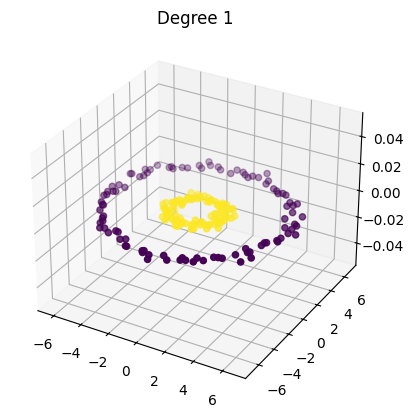

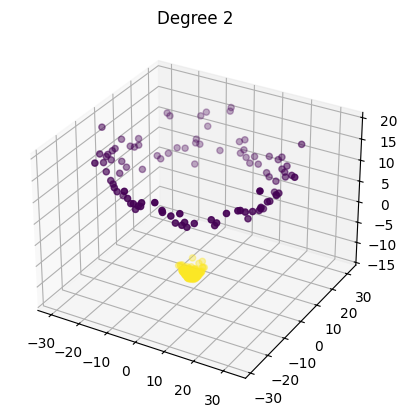

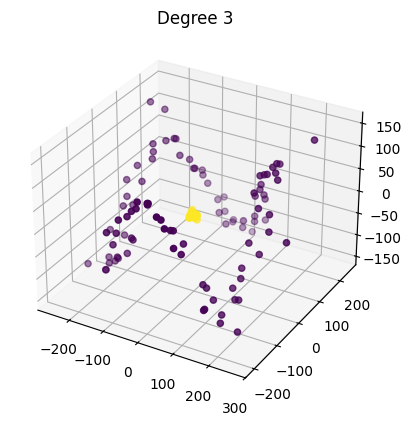

In [19]:
for i in range(1, 4):
    kpca_l = KernelPCA(n_components=3, kernel="poly", degree = i, gamma=10, alpha=0.1)
    X_kpca_l = kpca_l.fit_transform(X_std)
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.scatter(X_kpca_l[:, 0], X_kpca_l[:, 1], X_kpca_l[:, 2], c=y, cmap='viridis')
    ax.set_title(f"Degree {i}")
    plt.show()


## KPCA con Kernel Gaussiano

Observa cómo se transforman los datos utilizando un kernel polinómico. Utiliza 3 valores distintos de $\gamma$

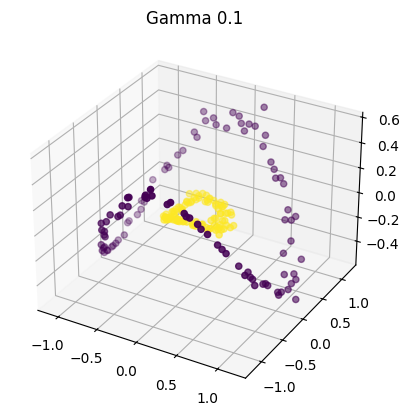

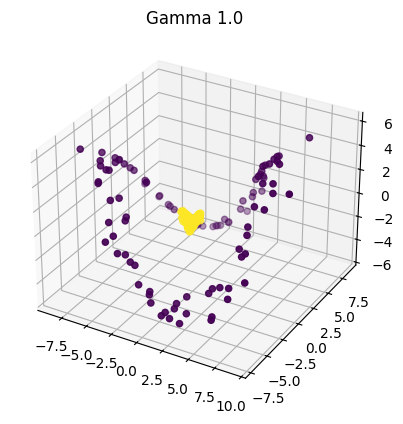

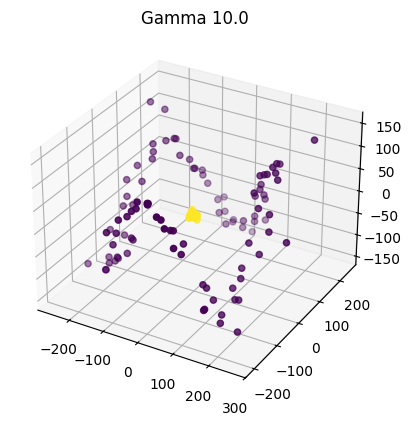

In [20]:
for i in np.array([0.1, 1, 10]):
    kpca_l = KernelPCA(n_components=3, kernel="poly", gamma = i, alpha=0.1)
    X_kpca_l = kpca_l.fit_transform(X_std)
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.scatter(X_kpca_l[:, 0], X_kpca_l[:, 1], X_kpca_l[:, 2], c=y, cmap='viridis')
    ax.set_title(f"Gamma {i}")
    plt.show()